In [818]:
import numpy as np
import pandas as pd
import random
# load et simulation function from simulate_population.py: 
from simulate_population import sim_population
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## 0) Simulate the data and test set (df_short and df_test)

In [4]:
# simulate data 
horizon = 10
pop = sim_population(N=20000, step_forward=horizon, randomseed=42+7)
df_short = pop.history[0].copy()
events = ["a", "b", "c", "d", "e"]
for e in events:
    df_short[f"time_{e}"] = df_short[f"time_{e}"].fillna(horizon)
    df_short[f"time_{e}"] = np.minimum(horizon, df_short[f"time_{e}"].fillna(horizon))

In [6]:
# simulate test data
pop_test = sim_population(N=5000, step_forward=horizon, randomseed=42+100+7)
df_test = pop_test.history[0].copy()
for e in events:
    df_test[f"time_{e}"] = df_test[f"time_{e}"].fillna(horizon)
    df_test[f"time_{e}"] = np.minimum(horizon, df_test[f"time_{e}"].fillna(horizon))

In [8]:
# concordance index calculations
from lifelines.utils import concordance_index
def get_cindex_for_event(predictions, df, event):
    time_col = f"time_{event}"
    risk_col = f"event_{event}"
    c = concordance_index(df[time_col], predictions, df[risk_col])
    return(c)

In [9]:
# X -> g(X, t, no time-varying covariates) -> g(X) * g0(t) <=> proportional hazards PH 
# time = age , but not a positional (same as in Delphi-2m), it is a context 
# binary outcomes t0 -> t1 , from age0 -> age1 
# batch should be stratified by outcome
# x-> FFW -> FFW -> fit a normal Cox Model to the embedding -> compute c-index -> update FFW weights ?
# This way we found embedding for the initial features, and fit a Cox model-> very transparent 
# multi-outcome: cause-specific Cox models for each variable 

# x → NN → single risk score -> minimize Cox loss


In [10]:
e = "a"
time_col = f"time_{e}"
event_col = f"event_{e}"

## Define classes

### CoxNN in pytorch

In [13]:
class CoxNN(nn.Module):
    def __init__(self, p, hidden_dims=(64, 32)):
        super().__init__()
        layers = []
        in_dim = p
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))  # scalar risk score
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)  # shape (n,)

# This is the same as 
#class CoxNN(nn.Module):
#    def __init__(self, p, hidden_dims = [64,32]):
#        super().__init__()
#        self.fc1 = nn.Linear(p, hidden_dims[0])
#        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
#        self.out = nn.Linear(hidden_dims[1], 1)  # scalar risk score#
#    def forward(self, x):
#        x = self.fc1(x)
#        x = F.relu(x)#
#        x = self.fc2(x)
#        x = F.relu(x)
#        x = self.out(x)
#        return x.squeeze(-1)  # shape (n,)

In [18]:
### Cox PH partial log-likelihood
def cox_partial_loglik(eta, time, event):
    """ eta: (n,) risk scores;     time: (n,) observed times;     event: (n,) 1 if event, 0 if censored """
    # sort by decreasing time
    order = torch.argsort(time, descending=True)
    eta = eta[order]
    event = event[order]
    # log cumulative sum of exp(eta)
    log_cumsum_exp = torch.logcumsumexp(eta, dim=0)
    # 3. contribution only from observed events
    loglik = eta[event == 1] - log_cumsum_exp[event == 1]
    return -loglik.sum()

In [20]:
def train_cox(x, time, event, hidden_dims = (), epochs = 10):
    p = len(x[0])
    model = CoxNN(p=p, hidden_dims = hidden_dims)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   
    for epoch in range(epochs):
        optimizer.zero_grad()
        eta = model(x)                     # risk scores
        loss = cox_partial_loglik(eta, time, event)
        loss.backward()
        optimizer.step()
        if ((epoch % 200 == 0)|(epoch +1 == epochs)):
            print(f"Epoch {epoch}, loss = {loss.item():.4f}")
    return (model)

In [22]:
# prepare the data 
def prepare_data_for_cox(df, 
                         covariate_cols = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"], 
                         event_type = "a"):
    time_col = f"time_{event_type}"
    event_col = f"event_{event_type}"
    x = torch.tensor( df[covariate_cols].values, dtype=torch.float32)
    time = torch.tensor( df[time_col].values, dtype=torch.float32)
    event = torch.tensor(df[event_col].values, dtype=torch.float32)
    return (x, time, event)

### CoxPH in lifelines

In [25]:
from lifelines import CoxPHFitter

def simplecox(df, covariate_cols = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"], event_type = "a"):
    time_col = f"time_{event_type}"
    event_col = f"event_{event_type}"
    cph = CoxPHFitter()
    cph.fit(df_short[[time_col, event_col] + covariate_cols], duration_col= time_col, event_col=event_col)
    #s=cph.summary[['coef', 'se(coef)', 'p']]
    #beta_cox = cph.params_.values
    return (cph)

## Examples

In [456]:
covariate_cols = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"]
event_to_check= "b"

#### a) Example1 - CoxPH from Lifelines:

In [459]:
cph = simplecox(df_short, covariate_cols= covariate_cols, event_type = event_to_check)
round(cph.summary[['coef', 'se(coef)', 'p']],4)

,coef,se(coef),p
covariate,,,
age_start,0.0284,0.0006,0.0000
bmi,-0.0049,0.0106,0.6414
hyp,0.5853,0.0200,0.0000
smoke,-0.0321,0.0241,0.1826
sex,-0.0112,0.0169,0.5089
eth1,-0.0129,0.0190,0.4969
eth2,0.0309,0.0286,0.2785


#### b) Example2 - CoxNN with no layers

In [461]:
# Checking that this gives usual Cox estimates with hidden_dims ==0
# coxn0 = CoxNN(p=5, hidden_dims = ())

In [464]:
x, time, event = prepare_data_for_cox(df_short,covariate_cols=covariate_cols, event_type = event_to_check)
coxn0 = train_cox(x,time,event, hidden_dims= (), epochs = 4000)

Epoch 0, loss = 226810.2500
Epoch 200, loss = 155569.0781
Epoch 400, loss = 130572.3594
Epoch 600, loss = 129978.1641
Epoch 800, loss = 129942.7031
Epoch 1000, loss = 129933.3984
Epoch 1200, loss = 129931.5703
Epoch 1400, loss = 129931.3125
Epoch 1600, loss = 129931.2656
Epoch 1800, loss = 129931.2734
Epoch 2000, loss = 129931.2812
Epoch 2200, loss = 129931.2734
Epoch 2400, loss = 129931.2812
Epoch 2600, loss = 129931.2734
Epoch 2800, loss = 129931.2734
Epoch 3000, loss = 129931.2734
Epoch 3200, loss = 129931.2734
Epoch 3400, loss = 129931.2734
Epoch 3600, loss = 129931.2734
Epoch 3800, loss = 129931.2734
Epoch 3999, loss = 129931.2734


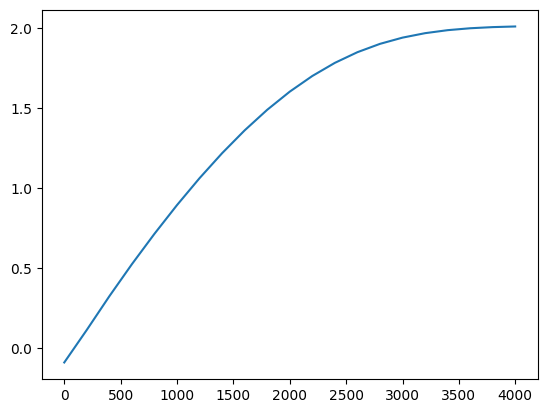

In [226]:
# learning the beta for eth2 == 2.00, or for eth1 == 0.50 (wouldnt work, but was before train_cox returned betas too
plt.plot(betas.index, betas.iloc[:,6])

In [289]:
# betas 
linear_layer = coxn0.net[0]
beta_nn = linear_layer.weight.detach().cpu().numpy().flatten()
bias_nn = linear_layer.bias.detach().cpu().numpy()
s["coef_CoxNN_1layer"] = beta_nn
s

,coef,se(coef),p,coef2,coef_CoxNN_1layer
covariate,,,,,
age_start,0.026313,0.000525,0.000000e+00,0.026312,0.026312
bmi,0.506781,0.008902,0.000000e+00,0.506771,0.506771
hyp,0.696061,0.019997,1.847556e-265,0.696033,0.696033
smoke,-0.026934,0.023678,2.553357e-01,-0.026936,-0.026936
sex,0.022082,0.016707,1.862397e-01,0.022082,0.022082
eth1,0.500646,0.018687,4.133464e-158,0.500602,0.500602
eth2,2.011789,0.027206,0.000000e+00,2.011612,2.011612


In [230]:
#After training:
#• eta = model(x) is the estimated log-risk
#• exp(eta) gives relative hazard
#• ordering of eta defines the risk ranking
#• no baseline hazard is estimated

#### b) Example2 - CoxNN with (16,16) layers

In [291]:
# Train a "real" CoxNN with hidden layers for encoding the covariates 
coxn = train_cox(x,time,event, hidden_dims= (16,16), epochs = 5000)

Epoch 0, loss = 135221.5156
Epoch 200, loss = 131310.0625
Epoch 400, loss = 130387.4844
Epoch 600, loss = 130387.0547
Epoch 800, loss = 130386.7734
Epoch 1000, loss = 130386.7188
Epoch 1200, loss = 130386.6797
Epoch 1400, loss = 130386.6797
Epoch 1600, loss = 130386.5000
Epoch 1800, loss = 130386.4375
Epoch 2000, loss = 130386.3281
Epoch 2200, loss = 130386.2969
Epoch 2400, loss = 130385.9688
Epoch 2600, loss = 130385.7891
Epoch 2800, loss = 130385.6172
Epoch 3000, loss = 130385.4375
Epoch 3200, loss = 130385.2812
Epoch 3400, loss = 130385.4688
Epoch 3600, loss = 130385.2812
Epoch 3800, loss = 130385.0156
Epoch 4000, loss = 130384.9375
Epoch 4200, loss = 130384.9531
Epoch 4400, loss = 130384.8438
Epoch 4600, loss = 130384.9062
Epoch 4800, loss = 130384.8750
Epoch 4999, loss = 130384.8125


### Comparison for CoxPH and CoxNN

In [292]:
# compute log-hazards from CoxPH 
risk1 = cph.predict_log_partial_hazard(df_test[covariate_cols])

In [293]:
# compute log-hazards from CoxNN
x_test = torch.tensor( df_test[covariate_cols].values, dtype=torch.float32)
risk2 = coxn0(x_test).detach().numpy() 

*--- Risk from CoxPH (x) and CoxNN_zero (y)---*


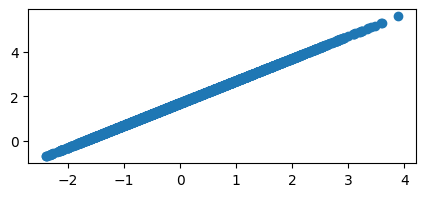

In [294]:
# plot one vs the other - should be the same 
import matplotlib.pyplot as plt
print ("*--- Risk from CoxPH (x) and CoxNN_zero (y)---*")
plt.figure(figsize = (5,2))
plt.scatter(risk1, risk2)

In [295]:
risk3 = coxn(x_test).detach().numpy() 

*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*


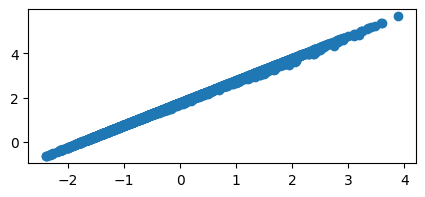

In [309]:
print ("*--- Risk from CoxPH (x) and CoxNN_REAL (y)---*")
plt.figure(figsize = (5,2))
plt.scatter(risk1, risk3)

In [311]:
# compute c-index and betas from CoxPH and CoxNN
#  coxn0: 
# the model CoxNN with hidden_dim=() reduces to exactly one layer nn.Linear(p, 1)
#• weights of shape (1, p)
#• bias enabled by default
# That bias is the only deviation from a standard CoxPH.
#• beta_nn corresponds to the Cox coefficients
#• bias_nn should ideally be ~0 (but shouldn’t exist in Cox)
# --cindex 
c1 = get_cindex_for_event(risk1*(-1), df= df_test, event= e)
c2 = get_cindex_for_event(risk2*(-1), df= df_test, event= e)
c3 = get_cindex_for_event(risk3*(-1), df= df_test, event= e)
# betas 
linear_layer = coxn0.net[0]
beta_nn = linear_layer.weight.detach().cpu().numpy().flatten()
bias_nn = linear_layer.bias.detach().cpu().numpy()

In [313]:
# Display results - diff between training Cox Loss in NN and CoxPH in lifelines

[ 0.02631237  0.50677073  0.6960332  -0.02693595  0.02208215  0.50060153
  2.0116122 ]
[ 0.02631286  0.50678091  0.69606134 -0.02693378  0.02208243  0.50064559
  2.01178914]
C_index for df_test: [0.72303 0.72302 0.72296]


C:\Users\dinab\AppData\Local\Temp\ipykernel_25028\3378356929.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.723' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  res.loc["Cindex", :] =  np.round([c1, c2, c3],3)


,CoxPH,CoxNN_0,CoxNN_1
covariate,,,
age_start,0.026,0.026,NaN
bmi,0.507,0.507,NaN
hyp,0.696,0.696,NaN
smoke,-0.027,-0.027,NaN
sex,0.022,0.022,NaN
eth1,0.501,0.501,NaN
eth2,2.012,2.012,NaN
Cindex,0.723,0.723,0.723


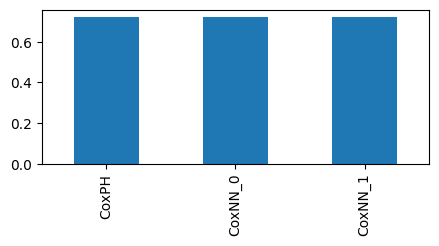

In [315]:
print(beta_nn)
print(beta_cox)
res = pd.DataFrame({"CoxPH" : cph.summary['coef']})
res["CoxNN_0"] = beta_nn
res["CoxNN_1"] = np.nan
res.loc["Cindex", :] =  np.round([c1, c2, c3],3)
res.loc["Cindex", :].plot.bar(figsize = (5,2))
print("C_index for df_test:", np.round([c1, c2, c3], 5))
np.round(res,3)

## All Cox in one go: 
### train and validate CoxPH, CoxNN_0 (no layers, equivalent to CoxPH) and CoxNN_1 

In [27]:
def check_outcome (df_short, df_test,
                   covariate_cols = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"],
                   hidden_dims= (16,16), 
                   event_type = "a", 
                   epoch1 = 10, 
                   epoch2 = 10): #better 4000
    # 1 simple cox
    cph = simplecox(df_short, covariate_cols, event_type)
    beta1 = cph.summary['coef']
    pval = np.round(cph.summary['p'],5)
    
    # 2 null deep cox 
    x, time, event = prepare_data_for_cox(df_short,covariate_cols, event_type)
    x_test, time_test, event_test = prepare_data_for_cox(df_test,covariate_cols, event_type)
    coxnull = train_cox(x, time, event, hidden_dims = (), epochs = epoch1) 
    linear_layer = coxnull.net[0]
    beta2 = linear_layer.weight.detach().cpu().numpy().flatten()
    #bias_nn = linear_layer.bias.detach().cpu().numpy()
    
    # 3 real deep cox
    coxreal = train_cox(x, time, event, hidden_dims = hidden_dims, epochs = epoch2) 
    
    # --cindex 
    risk1 = cph.predict_log_partial_hazard(df_test[covariate_cols])
    risk2 = coxnull(x_test).detach().numpy() 
    risk3 = coxreal(x_test).detach().numpy() 
    c1 = get_cindex_for_event(risk1*(-1), df = df_test, event = event_type)
    c2 = get_cindex_for_event(risk2*(-1), df = df_test, event = event_type)
    c3 = get_cindex_for_event(risk3*(-1), df = df_test, event = event_type)
    
    # betas
    betas = pd.DataFrame({"event": event_type, "pval": pval, "CoxPH": beta1, "CoxNN_null": beta2, "CoxNN_real": np.nan})
    betas.index = cph.summary['coef'].index
    cind = np.array([c1, c2, c3], dtype=np.float32)
    
    models = [];  models.append(cph);     models.append(coxnull);     models.append(coxreal)
    
    return models, betas, cind 

In [29]:
# r1 = check_outcome(df_short, event_type="b"); r1[1]

In [31]:
# we will run the above function for each event one by one 
# store all the models (cox, coxm0 and coxnn in models for each event)
# models [outcome number 0-"a", ... 3-"e"][model number 0-coxph, 1-coxn0, 2-coxnn]
res = []; models = []; cinds = []
events = ["a", "b", "c", "d", "e"]
for e in events:
    print(e)
    model_e, res_e, cind_e = check_outcome (df_short,df_test, hidden_dims= (16,16), event_type = e,epoch1=4000, epoch2=5000)
    res.append(res_e);     models.append(model_e); cinds.append(cind_e)    
res = pd.concat(res, axis=0)
cinds = pd.DataFrame(cinds); cinds.index = events; cinds.columns = ["CoxPH","CoxNN_null","CoxNN_real"]

a
Epoch 0, loss = 236304.4531
Epoch 200, loss = 161819.0469
Epoch 400, loss = 132840.8594
Epoch 600, loss = 131661.3438
Epoch 800, loss = 131258.4531
Epoch 1000, loss = 131002.8672
Epoch 1200, loss = 130820.6719
Epoch 1400, loss = 130683.7812
Epoch 1600, loss = 130581.6094
Epoch 1800, loss = 130508.1406
Epoch 2000, loss = 130457.9844
Epoch 2200, loss = 130425.8359
Epoch 2400, loss = 130406.6406
Epoch 2600, loss = 130396.0781
Epoch 2800, loss = 130390.7656
Epoch 3000, loss = 130388.3672
Epoch 3200, loss = 130387.3828
Epoch 3400, loss = 130387.0312
Epoch 3600, loss = 130386.9297
Epoch 3800, loss = 130386.8906
Epoch 3999, loss = 130386.8750
Epoch 0, loss = 141944.4375
Epoch 200, loss = 132528.6875
Epoch 400, loss = 131144.0938
Epoch 600, loss = 130404.7422
Epoch 800, loss = 130386.9531
Epoch 1000, loss = 130386.9297
Epoch 1200, loss = 130386.9141
Epoch 1400, loss = 130386.8906
Epoch 1600, loss = 130386.8672
Epoch 1800, loss = 130386.8281
Epoch 2000, loss = 130386.7812
Epoch 2200, loss = 1

## Results

<Axes: >

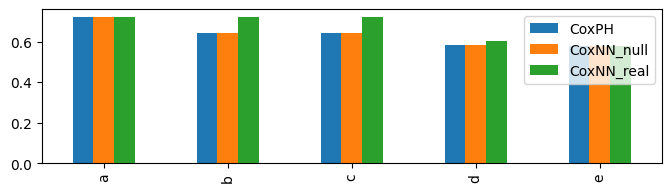

In [33]:
cinds.plot.bar(figsize = (8,2))

In [34]:
cinds

,CoxPH,CoxNN_null,CoxNN_real
a,0.723025,0.723024,0.722818
b,0.640725,0.640726,0.722396
c,0.641725,0.641725,0.720871
d,0.585915,0.585915,0.602136
e,0.580715,0.580716,0.577239


In [35]:
res

,event,pval,CoxPH,CoxNN_null,CoxNN_real
covariate,,,,,
age_start,a,0.00000,0.026313,0.026308,NaN
bmi,a,0.00000,0.506781,0.506678,NaN
hyp,a,0.00000,0.696061,0.695927,NaN
smoke,a,0.25534,-0.026934,-0.026931,NaN
sex,a,0.18624,0.022082,0.022077,NaN
eth1,a,0.00000,0.500646,0.500311,NaN
eth2,a,0.00000,2.011789,2.010232,NaN
age_start,b,0.00000,0.028392,0.028392,NaN
bmi,b,0.64138,-0.004937,-0.004934,NaN


## Multi-outcome CoxNN

In [37]:
#By default, nn.Linear(in_dim, K) includes a bias term (one per outcome).
#Just like in the single-outcome Cox case:
#the bias cancels out in the partial likelihood
#but it’s cleaner and more identifiable to remove it

# K - number of events (K outcomes)
class MultiCoxNN(nn.Module):
    def __init__(self, p, hidden_dims=(64, 32), K=5):
        super().__init__()
        layers = []
        in_dim = p
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, K,bias=False))  #  risk score for each of the K outcomes
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)  # shape (n,k)

*What it is*:
K independent cause-specific Cox models sharing all hidden layers and trained jointly; borrowing strength across outcomes.

*What it is not*: a competing-risks softmax model, a Fine–Gray model, a joint likelihood over mutually exclusive events.

In [39]:
# prepare the data for multi-outcome
covariate_cols = ["age_start", "bmi", "hyp","smoke", "sex", "eth1", "eth2"]
time_cols = ["time_a", "time_b", "time_c", "time_d","time_e"]
event_cols = ["event_a", "event_b", "event_c", "event_d","event_e"]
x2 = torch.tensor( df_short[covariate_cols].values, dtype=torch.float32)
time2 = torch.tensor( df_short[time_cols].values, dtype=torch.float32)
event2 = torch.tensor(df_short[event_cols].values, dtype=torch.float32)


In [41]:
def train_coxmulti(x2, time2, event2, hidden_dims = (), epochs = 300, K=5):
    p = len(x2[0])
    # p -number of initial params, len(covariate_cols)
    model = MultiCoxNN(p=p, K=K, hidden_dims = hidden_dims)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)   
    for epoch in range(epochs):
        optimizer.zero_grad()
        eta2 = model(x2)                     # risk scores
        loss = 0
        for k in range(K):
            loss += cox_partial_loglik(
            eta2[:, k],
            time2[:, k],
            event2[:, k])
        loss = loss / K
        loss.backward()
        optimizer.step()
        if ((epoch % 50 == 0)|(epoch +1 == epochs)):
            print(f"Epoch {epoch}, loss = {loss.item():.4f}")
    return (model)

### Train the multicox models, empty and actual one 

In [43]:
coxmmulti_null = train_coxmulti(x2, time2, event2, hidden_dims = ())

Epoch 0, loss = 125596.7266
Epoch 50, loss = 86263.6250
Epoch 100, loss = 85582.2031
Epoch 150, loss = 85464.5859
Epoch 200, loss = 85410.8750
Epoch 250, loss = 85388.0391
Epoch 299, loss = 85380.5625


In [44]:
coxmmulti = train_coxmulti(x2, time2, event2, hidden_dims = (64,64))

Epoch 0, loss = 88925.5469
Epoch 50, loss = 85377.3828
Epoch 100, loss = 84592.3906
Epoch 150, loss = 84521.6719
Epoch 200, loss = 84513.8672
Epoch 250, loss = 84458.9609
Epoch 299, loss = 84409.5156


In [45]:
coxmmulti_null(x2)[0,:]

tensor([1.3010, 1.0958, 0.5124, 0.2684, 0.3251], grad_fn=<SelectBackward0>)

### Compare the models - multi with one event

In [48]:
## We will compare the cindex and correlation of the predictions for the df_test 

def corr_with_coxph(risk, risk_coxph):
    return np.corrcoef(risk, risk_coxph)[0, 1]

def evaluate_all_models_cindex(    models,    coxmmulti_null,    coxmmulti,  
                               df_test,    covariate_cols,    time_cols,    event_cols,    events):
    """
    models[outcome][model]:
        model 0 = CoxPH
        model 1 = CoxNN_00
        model 2 = CoxNN_(64,64)
    """
    x_test = torch.tensor(df_test[covariate_cols].values,dtype=torch.float32    )
    rows = []
    corr_rows=[]
    # evaluate multi-output models once
    with torch.no_grad():
        risk_multi_null = coxmmulti_null(x_test).numpy()
        risk_multi      = coxmmulti(x_test).numpy()

    for k, e in enumerate(events):
        time_col  = time_cols[k]
        event_col = event_cols[k]
        # ---- single-event models ----
        cph   = models[k][0]
        coxn0 = models[k][1]
        coxn  = models[k][2]
        risk_cph = cph.predict_log_partial_hazard(df_test[covariate_cols]).values
        with torch.no_grad():
            risk_coxn0 = coxn0(x_test).numpy().squeeze()
            risk_coxn  = coxn(x_test).numpy().squeeze()
        row = {
            "event": e,
            "CoxPH": get_cindex_for_event( -risk_cph, df_test, e),
            "CoxNull": get_cindex_for_event( -risk_coxn0, df_test, e),
            "CoxReal": get_cindex_for_event(-risk_coxn, df_test, e),
            "MultiCoxNull": get_cindex_for_event(-risk_multi_null[:, k], df_test, e),
            "MultiCoxReal": get_cindex_for_event(-risk_multi[:, k], df_test, e),
        }
        rows.append(row)
        # ---------- correlation w/ CoxPH ----------
        corr_rows.append({
            "event": e,
            "CoxPH": 1.0,  # self-correlation
            "CoxNull": corr_with_coxph( risk_coxn0, risk_cph           ),
            "CoxReal": corr_with_coxph(                risk_coxn, risk_cph            ),
            "MultiCoxNull": corr_with_coxph(                risk_multi_null[:, k], risk_cph           ),
            "MultiCoxReal": corr_with_coxph(                risk_multi[:, k], risk_cph            ),
        })
        
    cindex_df = pd.DataFrame(rows).set_index("event")
    corr_df = pd.DataFrame(corr_rows).set_index("event")
    
    return cindex_df, corr_df


In [49]:
# run results aggregation function "evaluate_all_models_cindex"
cindex_results, corr_results = evaluate_all_models_cindex( models,   
                                                          coxmmulti_null,
                                                          coxmmulti,
                                                          df_test,
                                                          covariate_cols,
                                                          time_cols,
                                                          event_cols,
                                                          events)

## Results 

*Events*:
* "a" linear times  (diabetes), b => higher prob of a
* "b" non-linear effect of bmi
* "c" non-linear effect of bmi plus smoking x age interaction term 
* "d"  accelerating with age, dependency on ethnicity
* "e"  any comorbidity => higher chances, otherwise weak dependency on eth

*Expectations*: 
1) We want CoxPH == CoxNN_00 == MultiCoxNN_00 for all events
2) We expect CoxNN_Real ~== MultiCoxNN_Real
3) We expect CoxNN_Real and MultiCoxNN_Real >> CoxPH, CoxNN_00 and MultiCoxNN_00 for non-linear events "b" and "c"


<Axes: title={'center': 'C-index'}, xlabel='event'>

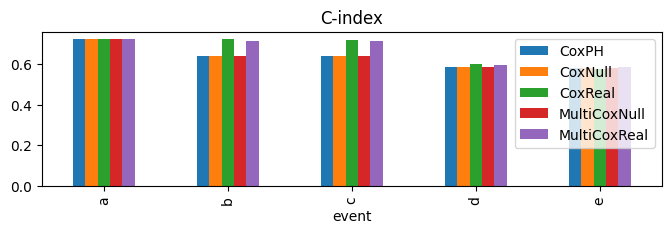

In [193]:
cindex_results.plot.bar(figsize = (8,2), title= "C-index")

In [53]:
np.round(cindex_results,4)

,CoxPH,CoxNull,CoxReal,MultiCoxNull,MultiCoxReal
event,,,,,
a,0.7230,0.7230,0.7228,0.7230,0.7228
b,0.6407,0.6407,0.7224,0.6407,0.7154
c,0.6417,0.6417,0.7209,0.6417,0.7118
d,0.5859,0.5859,0.6021,0.5859,0.5950
e,0.5807,0.5807,0.5772,0.5807,0.5840


In [54]:
print("*** Correlation in predictions for test set ***")
corr_results.T

*** Correlation in predictions for test set ***


event,a,b,c,d,e
CoxPH,1.000000,1.000000,1.000000,1.000000,1.000000
CoxNull,1.000000,1.000000,1.000000,1.000000,1.000000
CoxReal,0.999702,0.642601,0.618720,0.658014,0.644273
MultiCoxNull,0.999695,1.000000,1.000000,1.000000,1.000000
MultiCoxReal,0.999429,0.714864,0.616346,0.919999,0.931576


In [55]:
# Betas from MultiCox 
last = coxmmulti_null.net[-1]
with torch.no_grad():
        W = last.weight.detach().cpu().numpy()   # shape (K, p)
multi_betas = pd.DataFrame(W, index= ["a", "b", "c", "d", "e"], columns = covariate_cols).T
 # multi_betas

In [56]:
# Add betas and compare with the previous betas FROM single outcome
res["CoxMultiNull"] = np.nan
for e in ["a", "b", "c", "d", "e"]:
    res.loc[res.event == e, "CoxMultiNull"] = multi_betas[e]

res.loc["eth2", ["CoxPH", "CoxNN_null", "CoxMultiNull"]]

,CoxPH,CoxNN_null,CoxMultiNull
covariate,,,
eth2,2.011789,2.010232,1.878242
eth2,0.030950,0.030950,0.030950
eth2,0.010411,0.010406,0.010406
eth2,0.490595,0.490594,0.490594
eth2,0.567675,0.567662,0.567664


# Same in the binary format 

* In continuous time (Cox),  h_k(t | x) = h0_k(t) * exp(η_k(x))

* In discrete time, split follow-up into intervals (t0, t1], (t1, t2], …, (t_{J-1}, tJ]

* Then, model the conditional hazard per interval:  P(event in interval j | at risk at start of j, x) = h_{kj}(x)

* Using a logistic link: logit(h_{kj}(x)) = α_{kj} + η_k(x)

Step 2 — Neural binomial model (exact R analogue)

Here is the exact PyTorch equivalent of:

glm(event ~ bmi + age + hyp + sex + factor(interval), family="binomial")

## Set up 

In [435]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class DiscreteTimeNN(nn.Module):
    def __init__(self, p, n_intervals, hidden_dims=(64, 32)):
        super().__init__()
        layers = []
        in_dim = p
        # hidden layers
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        # output = eta (scalar)
        layers.append(nn.Linear(in_dim, 1, bias=False))
        self.net = nn.Sequential(*layers)
        # baseline hazard
        self.alpha = nn.Parameter(torch.zeros(n_intervals))
        
    def forward(self, x, interval_idx):
        eta = self.net(x).squeeze()
        logit = eta + self.alpha[interval_idx]
        return logit
        
    def get_eta(self, x):
        """Extract f(x)"""
        return self.net(x).squeeze()
        
    def predict_survival(self, x):
        """Predict survival probabilities for all intervals"""
        # eta: (n,)
        eta = self.net(x).squeeze()   # or self.beta(x) if linear
        # expand to (n, n_intervals)
        eta = eta.unsqueeze(1)  # (n, 1)
        alpha = self.alpha.unsqueeze(0)  # (1, n_intervals)
        logits = eta + alpha  # (n, n_intervals)
        hazards = torch.sigmoid(logits)  # (n, n_intervals)
        survival_probs = torch.cumprod(1 - hazards, dim=1)
        return survival_probs
        
    def return_logits(self, x):
        # eta: (n,)
        eta = self.net(x).squeeze()   # or self.beta(x) if linear
        # expand to (n, n_intervals)
        eta = eta.unsqueeze(1)  # (n, 1)
        alpha = self.alpha.unsqueeze(0)  # (1, n_intervals)
        logits = eta + alpha  # (n, n_intervals)
        return logits
        
    def return_hazards(self, x):
        eta = self.net(x).squeeze()   # or self.beta(x) if linear
        eta = eta.unsqueeze(1)  # (n, 1)
        alpha = self.alpha.unsqueeze(0)  # (1, n_intervals)
        logits = eta + alpha  # (n, n_intervals)
        hazards = torch.sigmoid(logits)  # (n, n_intervals)
        return hazards

    def return_etas(self, x):
        eta = self.net(x).squeeze()   # or self.beta(x) if linear
        return  eta.unsqueeze(1)

In [438]:
def train_model(model, X, interval_indices, events, lr=0.01, epochs=100):
    """
    Train the discrete time survival model
    Parameters:
    - X: tensor of covariates [n_samples, n_features]
    - interval_indices: tensor of interval indices [n_samples]
    - events: tensor of event indicators (0/1) [n_samples]
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        # Forward pass
        logits = model(X, interval_indices)
        
        # Binary cross-entropy loss (equivalent to binomial deviance)
        loss = F.binary_cross_entropy_with_logits(logits, events.float())
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 25 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')
    
    return model

In [440]:
# Function to prepare data for a specific event
import numpy as np

def prepare_data_for_event(df, event_type, features, n_intervals=50, even_split=False, event_ratio=0.8):

    events = df[f'event_{event_type}'].values
    times = df[f'time_{event_type}'].values
    X = df[features].values

    if even_split:
        # equal-width bins
        max_time = times.max()
        interval_width = max_time / n_intervals
        time_intervals = np.floor(times / interval_width).astype(int)
        time_intervals = np.clip(time_intervals, 0, n_intervals - 1)

    else:
        # split times
        event_times = np.sort(times[events == 1])
        cens_times  = np.sort(times[events == 0])

        # number of cuts
        n_event = int(n_intervals * event_ratio)
        n_cens  = n_intervals - n_event

        # quantile-based cuts
        event_cuts = np.quantile(event_times, np.linspace(0, 1, n_event + 2)[1:-1])
        cens_cuts  = np.quantile(cens_times,  np.linspace(0, 1, n_cens + 2)[1:-1])

        # combine + clean
        cut_points = np.sort(np.concatenate([event_cuts, cens_cuts]))
        cut_points = np.unique(np.round(cut_points, 6))

        # ensure correct number of intervals
        # (digitize creates len(cuts)+1 bins)
        if len(cut_points) > n_intervals - 1:
            cut_points = cut_points[:n_intervals - 1]

        # map times → interval indices
        time_intervals = np.digitize(times, bins=cut_points, right=True)

        # ensure bounds
        time_intervals = np.clip(time_intervals, 0, n_intervals - 1)

    return X, time_intervals, events, n_intervals

In [475]:
# Training function
def train_event_model(df, event_type, features, lr=0.002, epochs=100, batch_size=512, n_intervals=20, hidden_dims= ()):
    """Train a model for a specific event type"""
    # Prepare data
    X, time_intervals, events, n_intervals = prepare_data_for_event(df, event_type, features, n_intervals)
    # Convert to PyTorch tensors
    X_tensor = torch.FloatTensor(X)
    intervals_tensor = torch.LongTensor(time_intervals)
    events_tensor = torch.FloatTensor(events)
    # Initialize model
    model = DiscreteTimeNN(len(features), n_intervals, hidden_dims = hidden_dims)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Training loop
    n_samples = X_tensor.shape[0]
    n_batches = (n_samples + batch_size - 1) // batch_size
    
    for epoch in range(epochs):
        total_loss = 0
        # Shuffle data
        indices = torch.randperm(n_samples)
        for i in range(n_batches):
            # Get batch
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, n_samples)
            batch_indices = indices[start_idx:end_idx]
            X_batch = X_tensor[batch_indices]
            intervals_batch = intervals_tensor[batch_indices]
            events_batch = events_tensor[batch_indices]
            
            # Forward pass
            logits = model(X_batch, intervals_batch)
            # Binary cross-entropy loss
            loss = F.binary_cross_entropy_with_logits(logits, events_batch)
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch_indices)
        avg_loss = total_loss / n_samples
        if ((epoch % 50 == 0) |(epoch +1 == epochs)):
            print(f'Event {event_type} - Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    return model

In [480]:
covariate_cols = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"]
# Train models for each event 
binary_models = {}
for event_type in ['a', 'b', 'c', 'd', 'e']:
    print(f"\nTraining model for event {event_type}...")
    binary_models[event_type] = train_event_model(df_short, event_type, covariate_cols,n_intervals= 100, epochs = 100)  


Training model for event a...
Event a - Epoch 1/100, Loss: 0.5627
Event a - Epoch 51/100, Loss: 0.0821
Event a - Epoch 100/100, Loss: 0.0467

Training model for event b...
Event b - Epoch 1/100, Loss: 10.9533
Event b - Epoch 51/100, Loss: 0.1057
Event b - Epoch 100/100, Loss: 0.0539

Training model for event c...
Event c - Epoch 1/100, Loss: 2.6427
Event c - Epoch 51/100, Loss: 0.0918
Event c - Epoch 100/100, Loss: 0.0489

Training model for event d...
Event d - Epoch 1/100, Loss: 0.8476
Event d - Epoch 51/100, Loss: 0.0585
Event d - Epoch 100/100, Loss: 0.0226

Training model for event e...
Event e - Epoch 1/100, Loss: 0.4103
Event e - Epoch 51/100, Loss: 0.0647
Event e - Epoch 100/100, Loss: 0.0241


In [481]:
# Train Deep Binary models for each event 
binary_models_nn = {}
for event_type in ['a', 'b', 'c', 'd', 'e']:
    print(f"\nTraining model for event {event_type}...")
    binary_models_nn[event_type] = train_event_model(df_short, event_type, covariate_cols, n_intervals= 100, epochs = 200, hidden_dims = (32,32))


Training model for event a...
Event a - Epoch 1/200, Loss: 0.5520
Event a - Epoch 51/200, Loss: 0.0819
Event a - Epoch 101/200, Loss: 0.0466
Event a - Epoch 151/200, Loss: 0.0408
Event a - Epoch 200/200, Loss: 0.0390

Training model for event b...
Event b - Epoch 1/200, Loss: 0.5740
Event b - Epoch 51/200, Loss: 0.0842
Event b - Epoch 101/200, Loss: 0.0470
Event b - Epoch 151/200, Loss: 0.0409
Event b - Epoch 200/200, Loss: 0.0381

Training model for event c...
Event c - Epoch 1/200, Loss: 0.6441
Event c - Epoch 51/200, Loss: 0.0907
Event c - Epoch 101/200, Loss: 0.0480
Event c - Epoch 151/200, Loss: 0.0402
Event c - Epoch 200/200, Loss: 0.0383

Training model for event d...
Event d - Epoch 1/200, Loss: 0.4564
Event d - Epoch 51/200, Loss: 0.0662
Event d - Epoch 101/200, Loss: 0.0242
Event d - Epoch 151/200, Loss: 0.0145
Event d - Epoch 200/200, Loss: 0.0119

Training model for event e...
Event e - Epoch 1/200, Loss: 0.3988
Event e - Epoch 51/200, Loss: 0.0631
Event e - Epoch 101/200,

In [484]:
# betas are in model.net[0].  Namely, beta = model.net[0].weight.detach().numpy().flatten()

# Put the binary coefficients into a dataframe to compare with previous coeffs from coxph
coef_binary = pd.DataFrame({e: binary_models[e].net[0].weight.detach().numpy().flatten() for e in ["a", "b", "c", "d", "e"]})
coef_binary.index = covariate_cols
coef_binary

,a,b,c,d,e
age_start,0.022634,0.037429,0.009065,0.000855,-0.003215
bmi,0.485664,-0.025220,-0.041713,0.018224,0.001939
hyp,0.633010,0.603863,0.132258,-0.050474,-0.046580
smoke,0.006051,0.017429,0.850529,-0.065487,0.001173
sex,-0.020240,0.111797,-0.089014,-0.051253,-0.085315
eth1,0.414073,0.064504,-0.102428,0.141177,0.033273
eth2,1.900309,0.028342,-0.054655,0.176883,0.300834


In [486]:
# Add betas to "res" with the previous betas 
res["Binary"] = np.nan
for e in ["a", "b", "c", "d", "e"]:
    res.loc[res.event == e, "Binary"] = coef_binary[e]

<Axes: title={'center': 'eth2'}>

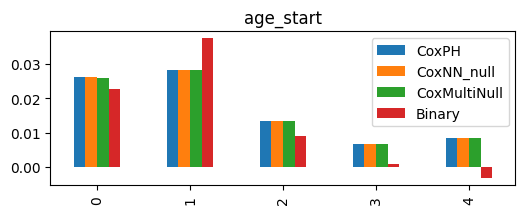

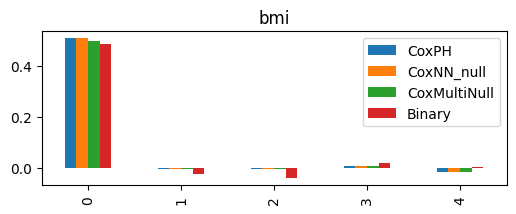

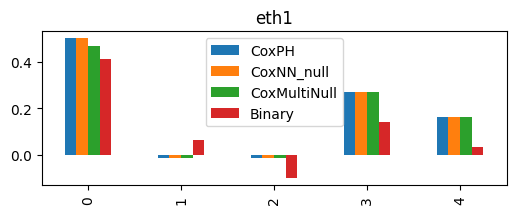

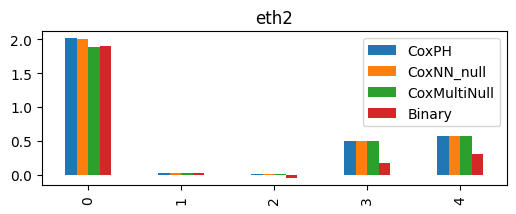

In [488]:
# plot them all
res.loc["age_start", ["CoxPH", "CoxNN_null", "CoxMultiNull", "Binary"]].reset_index().plot.bar(figsize=(6,2), title= "age_start")
res.loc["bmi", ["CoxPH", "CoxNN_null", "CoxMultiNull", "Binary"]].reset_index().plot.bar(figsize=(6,2), title= "bmi")
res.loc["eth1", ["CoxPH", "CoxNN_null", "CoxMultiNull", "Binary"]].reset_index().plot.bar(figsize=(6,2), title= "eth1")
res.loc["eth2", ["CoxPH", "CoxNN_null", "CoxMultiNull", "Binary"]].reset_index().plot.bar(figsize=(6,2), title ="eth2")

# Results - Cox + binary

In [490]:
res.loc[res.event == "a", ["pval", "CoxPH", "Binary"]]

,pval,CoxPH,Binary
covariate,,,
age_start,0.00000,0.026313,0.022634
bmi,0.00000,0.506781,0.485664
hyp,0.00000,0.696061,0.633010
smoke,0.25534,-0.026934,0.006051
sex,0.18624,0.022082,-0.020240
eth1,0.00000,0.500646,0.414073
eth2,0.00000,2.011789,1.900309


Got it — you want the **raw logits (η + α_j)**, not survival. That’s perfectly reasonable, especially if you want something closer to a **linear predictor analogue**.

Since logits are: $logit$ $h_{ij}$  $= x_i^\top \beta + alpha_j$

**You have three valid “outputs”:**

1 **eta (βx)** → best for Cox comparison ✅

2 **logits (η + α_j)** → interval-specific modeling

3 **survival / risk** → absolute prediction

In [530]:
# compute and compare C-index
events_list = ['a', 'b', 'c', 'd', 'e']
cind_binary_eta ={}
cind_binary_eta2={}
X_test = torch.tensor(df_test[covariate_cols].values, dtype=torch.float32)
for e in events_list:
    modeli = binary_models[e]
    modelii = binary_models_nn[e]
    modeli.eval()
    modelii.eval()
    with torch.no_grad():
        # survival probabilities (n, n_intervals)
        #survival  = modeli.predict_survival(X_test).cpu().numpy()
        #risk = 1 - survival[:, 2] 
        #cind_binary[e] = get_cindex_for_event(-risk, df_test, e)
        eta = modeli.return_etas(X_test).cpu().numpy()
        eta2 = modelii.return_etas(X_test).cpu().numpy()
        cind_binary_eta[e] = get_cindex_for_event(-eta, df_test, e)
        cind_binary_eta2[e] = get_cindex_for_event(-eta2, df_test, e)
#! somehow survival is very low and goes to 0 at some point causing the c-index to be 0.5 as all survival is 0
# etas are ok, and survival at times 0-5 are exactly the same c-indeces

In [497]:
pd.DataFrame({"cindex_bin": pd.Series(cind_binary_eta), "cindex_bin_deep": pd.Series(cind_binary_eta2)})

,cindex_bin,cindex_bin_deep
a,0.722444,0.720508
b,0.639549,0.696592
c,0.635839,0.703196
d,0.578346,0.550773
e,0.503461,0.575659


In [500]:
cindex_results["Binary_linear"] = pd.Series(cind_binary_eta)
cindex_results["Binary_Deep"] = pd.Series(cind_binary_eta2)
cindex_results

,CoxPH,CoxNull,CoxReal,MultiCoxNull,MultiCoxReal,Binary_linear,Binary_Deep
event,,,,,,,
a,0.723025,0.723024,0.722818,0.723006,0.722838,0.722444,0.720508
b,0.640725,0.640726,0.722396,0.640726,0.715431,0.639549,0.696592
c,0.641725,0.641725,0.720871,0.641725,0.711788,0.635839,0.703196
d,0.585915,0.585915,0.602136,0.585914,0.594965,0.578346,0.550773
e,0.580715,0.580716,0.577239,0.580716,0.584038,0.503461,0.575659


<Axes: xlabel='event'>

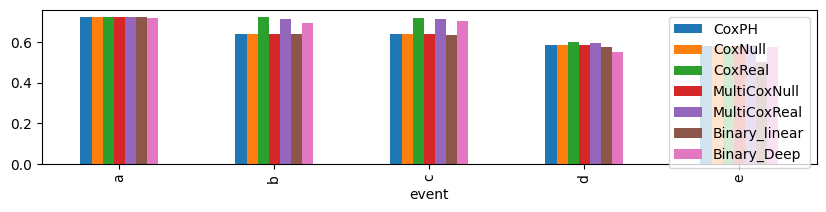

In [506]:
cindex_results.plot.bar(figsize = (10,2))

# How the data is inserted into the models

| Model                                 | Time Representation        | Data Shape              | Input to Model                             | Output (η / logits)            | Loss Function                  | Baseline Handling                             | Key Interpretation                |
| ------------------------------------- | -------------------------- | ----------------------- | ------------------------------------------ | ------------------------------ | ------------------------------ | --------------------------------------------- | --------------------------------- |
| **CoxPH (lifelines)**                 | Continuous                 | (n, p)                  | DataFrame with `time`, `event`, covariates | Linear predictor ( x\beta )    | Partial likelihood             | Implicit (baseline hazard estimated post-hoc) | Classical proportional hazards    |
| **CoxNN**                             | Continuous                 | (n, p)                  | `x` tensor                                 | ( \eta = f(x) ) (scalar)       | Partial likelihood             | Implicit                                      | Nonlinear Cox model               |
| **MultiCoxNN**                        | Continuous (multi-event)   | (n, p, K)               | `x`, `time[:,k]`, `event[:,k]`             | ( \eta_k = f_k(x) )            | Sum of Cox partial likelihoods | Implicit per outcome                          | Joint modelling of multiple risks |
| **Discrete-time Binary (your model)** | Discretised time intervals | (n, p) + interval index | `x`, `interval_idx`                        | ( \eta(x) + \alpha_t ) (logit) | Binary cross-entropy           | Explicit via ( \alpha_t )                     | Piecewise hazard model            |


| Aspect             | Cox-type models           | Discrete-time binary                  |
| ------------------ | ------------------------- | ------------------------------------- |
| Time usage         | Ordering only (risk sets) | Explicit time bins                    |
| Censoring handling | Built into likelihood     | Implicit via labels                   |
| Baseline hazard    | Not learned directly      | Learned as parameters                 |
| Output meaning     | Relative risk             | Interval-specific hazard probability  |
| Data expansion     | None                      | (yours: none; classical: long format) |


Why Cox could not be bactched in this implementation?

| Model                | Can batch?                 | Why                                |
| -------------------- | -------------------------- | ---------------------------------- |
| CoxPH                | ❌                          | Needs full risk sets               |
| CoxNN                | ❌ (in your implementation) | Same partial likelihood constraint |
| MultiCoxNN           | ❌                          | Same, just repeated over outcomes  |
| Binary discrete-time | ✅                          | Independent observations           |


# Multi Binary

In the binary case you need to be explicit about whether you’re modelling independent outcomes or something like competing risks. I’ll assume (consistent with your setup) that these are separate event processes, so summing losses is appropriate.

Sum the losses across the outcomes

* In Cox losses are conditionally dependent via risk sets but still separable across outcomes → sum
* In binary losses are fully independent summing is exact, not an approximation

You now need:
* X                      # (n, p)
* time_intervals         # (n, K)
* events                 # (n, K)


| CoxMulti                 | BinaryMulti                  |
| ------------------------ | ---------------------------- |
| $\eta_k(x)$              | $\eta_k(x) + \alpha_{t,k}$   |
| partial likelihood per k | BCE per k                    |
| sum over k               | sum over k                   |


In [598]:

class MultiDiscreteTimeNN(nn.Module):
    def __init__(self, p, n_intervals, K, hidden_dims=()):
        super().__init__()
        # -------- feature network (eta) --------
        layers = []
        in_dim = p
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, K, bias=False))  # (n, K)
        self.net = nn.Sequential(*layers)
        # -------- baseline hazards:  
        # alpha[k, t] = baseline logit for outcome k at interval t
        self.alpha = nn.Parameter(torch.zeros(K, n_intervals))

    def forward(self, x, interval_idx):
        """       x:            (n, p)        interval_idx: (n, K)   integers in [0, n_intervals-1]         """
        eta = self.net(x) # (n, K)
        n, K = interval_idx.shape
        # create outcome indices: (n, K)
        k_idx = torch.arange(K, device=x.device).unsqueeze(0).expand(n, K)
        # safe lookup: alpha[k, t_ik]
        alpha_k = self.alpha[k_idx, interval_idx]  # (n, K)
        logits = eta + alpha_k
        return logits

    def get_eta(self, x):
        """Return linear predictors (no baseline)"""
        return self.net(x)

In [750]:
#prepare data for multibinary
def prepare_data_for_multibinary (df, features, event_types = ["a","b","c","d","e"], 
                                  n_intervals=10, even_split=False, event_ratio=0.8):
    time_cols  = [f"time_{e}" for e in event_types]
    event_cols = [f"event_{e}" for e in event_types]
    times  = df[time_cols].values        # (n, K)
    events = df[event_cols].values       # (n, K)
    K = len(event_types)
    time_intervals = np.zeros_like(times, dtype=int)
    for kk in range(K):
        _, ti_k, _, _ = prepare_data_for_event(
            df, event_type=event_types[kk], features=features, 
            n_intervals=n_intervals,  even_split=even_split, event_ratio= event_ratio)
        time_intervals[:, kk] = ti_k
    return df[features].values, time_intervals, events, n_intervals

In [754]:
def train_binmulti(    X,    time_intervals,    events,    n_intervals,
    hidden_dims=(),    lr=0.01,    epochs=300,    batch_size=1024):
    """     Train multi-outcome discrete-time binary model    (strict analogue of train_coxmulti)    """
    n, p = X.shape
    K = events.shape[1]
    X_tensor = torch.FloatTensor(X)
    intervals_tensor = torch.LongTensor(time_intervals)   # (n, K)
    events_tensor = torch.FloatTensor(events)             # (n, K)
    model = MultiDiscreteTimeNN(p=p, n_intervals=n_intervals, K=K, hidden_dims=hidden_dims)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n_batches = (n + batch_size - 1) // batch_size
    # training loop
    for epoch in range(epochs):
        perm = torch.randperm(n)
        total_loss = 0.0
        for i in range(n_batches):
            idx = perm[i * batch_size : (i + 1) * batch_size]
            X_b = X_tensor[idx]
            intervals_b = intervals_tensor[idx]   # (b, K)
            events_b = events_tensor[idx]         # (b, K)
            # forward
            logits = model(X_b, intervals_b)      # (b, K)
            # -------- strict Cox analogy --------
            loss = 0.0
            for k in range(K): loss += F.binary_cross_entropy_with_logits(logits[:, k],events_b[:, k])
            loss = loss / K
            # backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(idx)

        avg_loss = total_loss / n
        if (epoch % 50 == 0) or (epoch + 1 == epochs):
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    return model

In [756]:
def get_cindex_multibinary(binmulti, df_test, covariate_cols):
    with torch.no_grad():
        eta = binmulti.get_eta(
            torch.FloatTensor(df_test[covariate_cols].values)
        ).cpu().numpy()
    cindex_dict = {}
    for k, e in enumerate(["a","b","c","d","e"]):
        risk = eta[:, k]
        cindex_dict[e] = get_cindex_for_event(-risk, df=df_test,event=e)
    return cindex_dict

In [758]:
X3, time_intervals3, events3, n_intervals3 = prepare_data_for_multibinary(df_short, covariate_cols, n_intervals= 10)
X3test, time_intervals3test, events3test, n_intervals3test = prepare_data_for_multibinary(df_test, covariate_cols)
binmulti = train_binmulti(X3, time_intervals3, events3, n_intervals3, epochs = 400, lr=0.01, batch_size=1024) 

Epoch 1/400, Loss: 1.2519
Epoch 51/400, Loss: 0.1433
Epoch 101/400, Loss: 0.1394
Epoch 151/400, Loss: 0.1383
Epoch 201/400, Loss: 0.1379
Epoch 251/400, Loss: 0.1377
Epoch 301/400, Loss: 0.1378
Epoch 351/400, Loss: 0.1375
Epoch 400/400, Loss: 0.1380


In [743]:
binmulti_deep = train_binmulti(X3, time_intervals3, events3, n_intervals3, 
                               hidden_dims = (32,32), epochs = 400, lr=0.005, batch_size=1024) 

Epoch 1/400, Loss: 0.5498
Epoch 51/400, Loss: 0.1502
Epoch 101/400, Loss: 0.1384
Epoch 151/400, Loss: 0.1360
Epoch 201/400, Loss: 0.1350
Epoch 251/400, Loss: 0.1345
Epoch 301/400, Loss: 0.1343
Epoch 351/400, Loss: 0.1338
Epoch 400/400, Loss: 0.1336


In [760]:
# Compare betas to Cox and others
beta = binmulti.net[0].weight.detach().cpu().numpy()  # shape (K, p)
res["BinaryMulti"] = np.nan 
for i,e in enumerate(events_list): res.loc[res.event == e, "BinaryMulti"] = beta[i]
res.loc[res.event == "a"]

,event,pval,CoxPH,CoxNN_null,CoxNN_real,CoxMultiNull,Binary,Binary_real,BinaryMulti
covariate,,,,,,,,,
age_start,a,0.00000,0.026313,0.026308,NaN,0.025912,0.022634,NaN,0.031842
bmi,a,0.00000,0.506781,0.506678,NaN,0.496965,0.485664,NaN,0.597787
hyp,a,0.00000,0.696061,0.695927,NaN,0.682085,0.633010,NaN,0.709607
smoke,a,0.25534,-0.026934,-0.026931,NaN,-0.026477,0.006051,NaN,-0.064361
sex,a,0.18624,0.022082,0.022077,NaN,0.021572,-0.020240,NaN,0.037021
eth1,a,0.00000,0.500646,0.500311,NaN,0.468909,0.414073,NaN,0.597563
eth2,a,0.00000,2.011789,2.010232,NaN,1.878242,1.900309,NaN,2.322125


In [762]:
# Compare cindex to Cox and others
cindex_results["MultiBinary_linear"] = get_cindex_multibinary(binmulti, df_test, covariate_cols)
cindex_results["MultiBinary_Deep"] = get_cindex_multibinary(binmulti_deep, df_test, covariate_cols)
cindex_results

,CoxPH,CoxNull,CoxReal,MultiCoxNull,MultiCoxReal,Binary_linear,Binary_Deep,MultiBinary_linear,MultiBinary_Deep
event,,,,,,,,,
a,0.723025,0.723024,0.722818,0.723006,0.722838,0.722444,0.720508,0.722407,0.718431
b,0.640725,0.640726,0.722396,0.640726,0.715431,0.639549,0.696592,0.639638,0.710686
c,0.641725,0.641725,0.720871,0.641725,0.711788,0.635839,0.703196,0.637036,0.707179
d,0.585915,0.585915,0.602136,0.585914,0.594965,0.578346,0.550773,0.557896,0.530518
e,0.580715,0.580716,0.577239,0.580716,0.584038,0.503461,0.575659,0.555619,0.566513


# TRANSFORMERS 

In [985]:
# Initialize and simulate 5 steps
population = sim_population(N=100, step_forward=2, randomseed=42)
for i in range(5):   population.step()
# Get the wide format dataframe
wide_df = population.to_wide_format()

print(f"Shape: {wide_df.shape}")
print(f"\nColumns: {wide_df.columns.tolist()}")
print(f"\nFirst few rows:")
wide_df.head()

# Save to CSV if needed
# wide_df.to_csv('population_wide_format.csv', index=False)

Shape: (100, 73)

Columns: ['id', 'age_start', 'bmi', 'hyp', 'smoke', 'sex', 'eth1', 'eth2', 'time_a_step0', 'event_a_step0', 'time_b_step0', 'event_b_step0', 'time_c_step0', 'event_c_step0', 'time_d_step0', 'event_d_step0', 'time_e_step0', 'event_e_step0', 'time_a_step1', 'event_a_step1', 'time_b_step1', 'event_b_step1', 'time_c_step1', 'event_c_step1', 'time_d_step1', 'event_d_step1', 'time_e_step1', 'event_e_step1', 'time_a_step2', 'event_a_step2', 'time_b_step2', 'event_b_step2', 'time_c_step2', 'event_c_step2', 'time_d_step2', 'event_d_step2', 'time_e_step2', 'event_e_step2', 'time_a_step3', 'event_a_step3', 'time_b_step3', 'event_b_step3', 'time_c_step3', 'event_c_step3', 'time_d_step3', 'event_d_step3', 'time_e_step3', 'event_e_step3', 'time_a_step4', 'event_a_step4', 'time_b_step4', 'event_b_step4', 'time_c_step4', 'event_c_step4', 'time_d_step4', 'event_d_step4', 'time_e_step4', 'event_e_step4', 'time_a_step5', 'event_a_step5', 'time_b_step5', 'event_b_step5', 'time_c_step5', 

,id,age_start,bmi,hyp,smoke,sex,eth1,eth2,time_a_step0,event_a_step0,...,event_c_step5,time_d_step5,event_d_step5,time_e_step5,event_e_step5,first_a,first_b,first_c,first_d,first_e
0,1,62.1,0.4,0,0,1,0,1,0.830,1,...,1,3.095,0,11.081,0,0.830,4.273,0.375,NaN,NaN
1,2,43.0,-0.9,0,0,0,0,0,36.349,0,...,1,287.094,0,76.805,0,3.550,NaN,10.647,NaN,NaN
2,3,66.9,-0.4,0,1,1,0,0,34.192,0,...,1,11.327,0,73.255,0,2.404,5.214,2.100,NaN,NaN
3,4,57.7,1.3,0,0,1,1,0,1.397,1,...,0,31.594,0,0.054,1,1.397,4.105,9.916,NaN,2.763
4,5,23.4,-0.4,0,0,0,0,0,85.543,0,...,0,7.147,0,77.988,0,NaN,NaN,4.443,NaN,NaN


In [987]:
wide_df.loc[wide_df.id ==5, :][["event_c_step2", "time_c_step2", "first_c"]]

,event_c_step2,time_c_step2,first_c
4,1,0.443,4.443


In [983]:
import importlib
from simulate_population import sim_population

# Force reload the module
importlib.reload(sys.modules['simulate_population'])

# Now import again
from simulate_population import sim_population


In [991]:
population.to_cox_format()

,id,age_start,bmi,hyp,smoke,sex,eth1,eth2,event_a,time_a,event_b,time_b,event_c,time_c,event_d,time_d,event_e,time_e
0,1,62.1,0.4,0,0,1,0,1,1,0.830,1,4.273,1,0.375,0,12.000,0,12.000
1,2,43.0,-0.9,0,0,0,0,0,1,3.550,0,12.000,1,10.647,0,12.000,0,12.000
2,3,66.9,-0.4,0,1,1,0,0,1,2.404,1,5.214,1,2.100,0,12.000,0,12.000
3,4,57.7,1.3,0,0,1,1,0,1,1.397,1,4.105,1,9.916,0,12.000,1,2.763
4,5,23.4,-0.4,0,0,0,0,0,0,12.000,0,12.000,1,4.443,0,12.000,0,12.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,53.9,1.5,1,0,1,1,0,1,0.229,1,3.520,1,4.522,1,3.036,1,10.062
96,97,38.6,-1.1,0,0,0,0,1,1,5.016,1,1.094,0,12.000,0,12.000,0,12.000
97,98,23.0,-0.9,0,0,1,1,0,1,1.983,1,7.977,0,12.000,0,12.000,0,12.000
98,99,24.7,0.6,0,0,1,0,0,1,1.359,1,3.826,0,12.000,0,12.000,0,12.000
